<a href="https://colab.research.google.com/github/undertow515/123123/blob/main/ffa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<Axes: title={'center': 'Streamflow Histogram'}, ylabel='Frequency'>

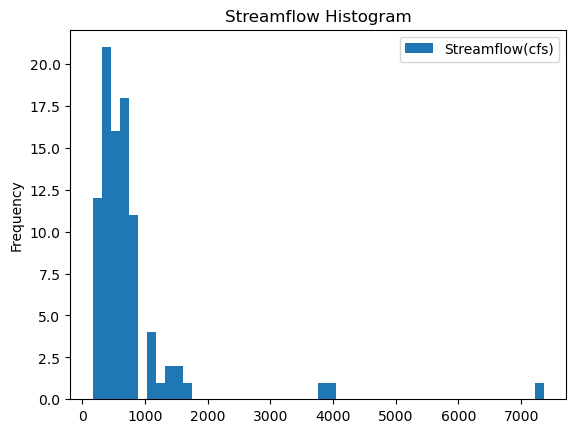

In [ ]:
import pandas as pd
df = pd.read_csv(r"https://raw.githubusercontent.com/undertow515/123123/refs/heads/main/flood_example_data.csv")
# remove "," from Streamflow column and convert to numeric

# First, we preprocess the data
df['Streamflow(cfs)'] = pd.to_numeric(df['Streamflow(cfs)'].str.replace(',', ''), errors='coerce')
df["Streamflow(cfs)"] = df["Streamflow(cfs)"].astype(float)
df.dropna(subset=['Streamflow(cfs)'], inplace=True)
df["Date"] = pd.to_datetime(df["Date"])
df.plot(kind="hist", y="Streamflow(cfs)", bins=50, title="Streamflow Histogram")



Fitted parameters for lognorm: (0.2375193151966037, 3.8387975951615623, 2.4532331159553573)


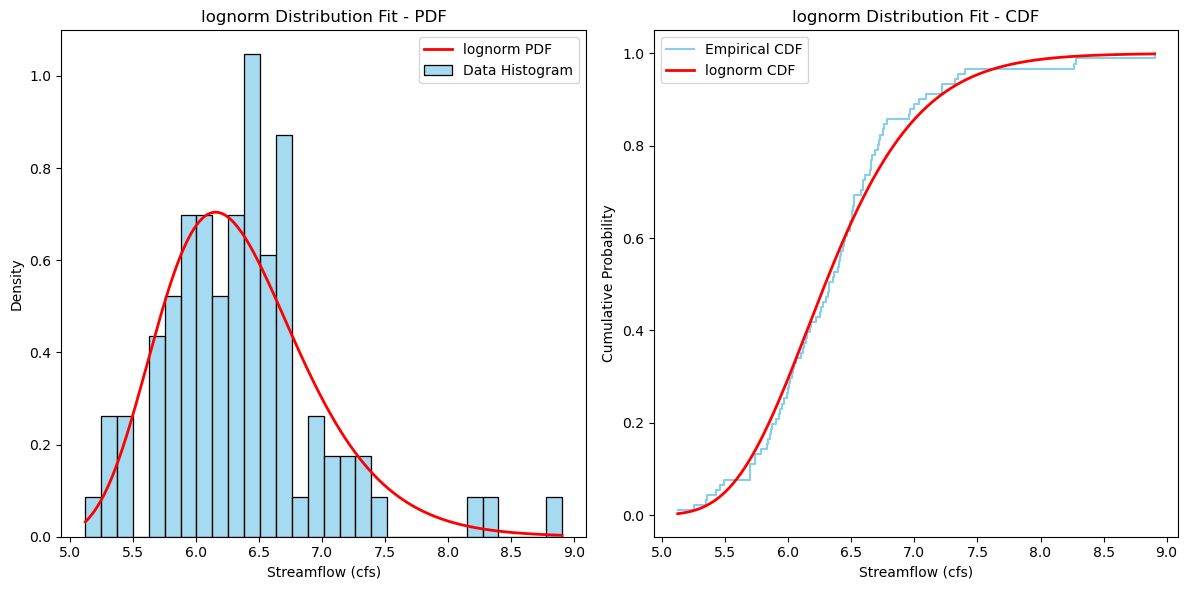

Fitted parameters for weibull_min: (2.184715538588837, 5.047885243918952, 1.4809868799535124)


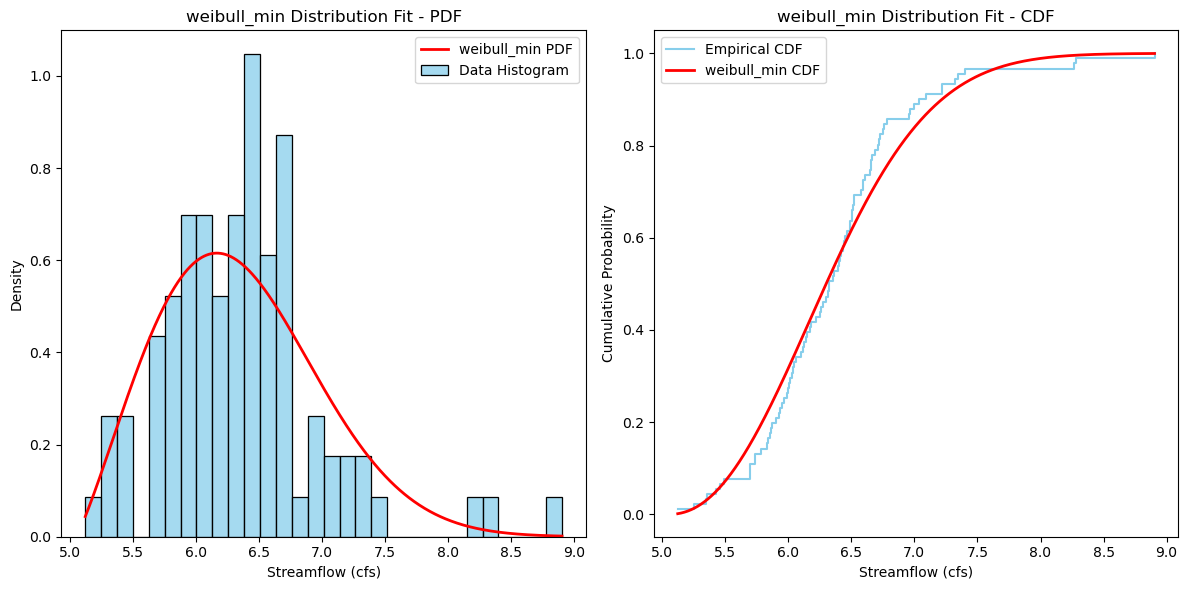

Fitted parameters for lp3: (0.6535580582228173, 6.362928732621517, 0.6072474181969039)


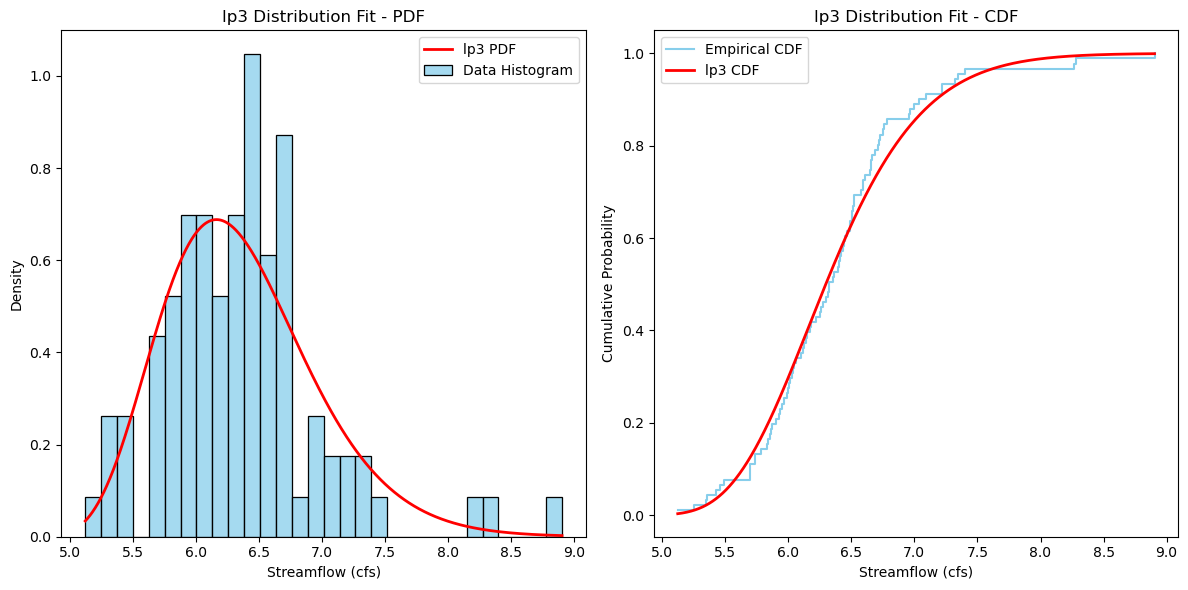

In [ ]:
# Then, we can perform some basic analysis on the streamflow data (Flood Frequency Analysis)
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

dist_dict = {
    "lognorm": stats.lognorm,
    "weibull_min": stats.weibull_min,
    "lp3": stats.pearson3,
}

def fit_distribution(data, dist_name):
    dist = dist_dict[dist_name]
    if dist_name == "lognorm":
        shape, loc, scale = dist.fit(data)
        return shape, loc, scale
    elif dist_name == "weibull_min":
        c, loc, scale = dist.fit(data)
        return c, loc, scale
    elif dist_name == "lp3":
        skew, loc, scale = dist.fit(data)
        return skew, loc, scale

def plot_distribution_fit_cdf(data, dist_name):
    dist = dist_dict[dist_name]
    params = fit_distribution(data, dist_name)

    # Generate x values
    x = np.linspace(min(data), max(data), 1000)

    # Calculate the PDF and CDF
    if dist_name == "lognorm":
        pdf = dist.pdf(x, params[0], loc=params[1], scale=params[2])
        cdf = dist.cdf(x, params[0], loc=params[1], scale=params[2])
    elif dist_name == "weibull_min":
        pdf = dist.pdf(x, params[0], loc=params[1], scale=params[2])
        cdf = dist.cdf(x, params[0], loc=params[1], scale=params[2])
    elif dist_name == "lp3":
        pdf = dist.pdf(x, params[0], loc=params[1], scale=params[2])
        cdf = dist.cdf(x, params[0], loc=params[1], scale=params[2])

    # Plotting
    plt.figure(figsize=(12, 6))
    # Histogram and PDF
    plt.subplot(1, 2, 1)
    sns.histplot(data, bins=30, kde=False, stat='density', color='skyblue', label='Data Histogram')
    plt.plot(x, pdf, 'r-', lw=2, label=f'{dist_name} PDF')
    plt.title(f'{dist_name} Distribution Fit - PDF')
    plt.xlabel('Streamflow (cfs)')
    plt.ylabel('Density')
    plt.legend()

    # CDF
    plt.subplot(1, 2, 2)


    ecdf = np.arange(1, len(data)+1) / len(data)
    sorted_data = np.sort(data)
    plt.step(sorted_data, ecdf, where='post', label='Empirical CDF', color='skyblue')
    plt.plot(x, cdf, 'r-', lw=2, label=f'{dist_name} CDF')
    plt.title(f'{dist_name} Distribution Fit - CDF')
    plt.xlabel('Streamflow (cfs)')
    plt.ylabel('Cumulative Probability')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Example usage
streamflow_data = df['Streamflow(cfs)'].values
log_streamflow_data = np.log(streamflow_data)
for dist_name in dist_dict.keys():
    # print fitted parameters
    params = fit_distribution(log_streamflow_data, dist_name)
    print(f"Fitted parameters for {dist_name}: {params}")
    plot_distribution_fit_cdf(log_streamflow_data, dist_name)

https://www.statisticshowto.com/kolmogorov-smirnov-test/

In [ ]:
# How dose we select the best fit distribution?
# In this time, we will use the Kolmogorov-Smirnov test to compare the empirical distribution with the fitted distributions.
# Anderson-Darling test can also be used for this purpose.
# AD-test is more sensitive to the tails of the distribution compared to the KS-test and more widely used in hydrology.
# And Akaike Information Criterion (AIC) to compare the goodness of fit among different distributions.

# Those three methods can be used together to select the best fit distribution with more confidence.

# First, we will implement the KS-test

def ks_test(data, dist_name):
    dist = dist_dict[dist_name]
    params = fit_distribution(data, dist_name)

    # Generate CDF values for the data
    if dist_name == "lognorm":
        cdf_fitted = dist.cdf(np.sort(data), params[0], loc=params[1], scale=params[2])
    elif dist_name == "weibull_min":
        cdf_fitted = dist.cdf(np.sort(data), params[0], loc=params[1], scale=params[2])
    elif dist_name == "lp3":
        cdf_fitted = dist.cdf(np.sort(data), params[0], loc=params[1], scale=params[2])

    # Empirical CDF
    ecdf = np.arange(1, len(data)+1) / len(data)

    # KS statistic
    ks_statistic = np.max(np.abs(ecdf - cdf_fitted)) # it is very easy to calculate the KS statistic using scipy.stats.kstest function, but here we calculate it manually for better understanding.




    # p-value
    n = len(data)
    p_value = stats.kstest(data, lambda x: dist.cdf(x, *params)).pvalue

    return ks_statistic, p_value

# Example usage
for dist_name in dist_dict.keys():
    ks_stat, p_val = ks_test(log_streamflow_data, dist_name)
    print(f"KS Test for {dist_name}: KS Statistic = {ks_stat}, p-value = {p_val}")

KS Test for lognorm: KS Statistic = 0.07967637677685191, p-value = 0.582305286885042
KS Test for weibull_min: KS Statistic = 0.10179805425378308, p-value = 0.28270839353271815
KS Test for lp3: KS Statistic = 0.08423368093946693, p-value = 0.5113805052504499


https://www.itl.nist.gov/div898/handbook/eda/section3/eda35e.htm

In [ ]:
# Anderson-Darling test

def ad_statistics(data, dist_name):
    dist = dist_dict[dist_name]
    params = dist.fit(data)
    S = 0
    s1 =  dist.cdf(np.sort(data), *params)
    s2 = 1 - dist.cdf(np.sort(data)[::-1], *params)
    s = np.log(s1) + np.log(s2)
    for s, i in zip(s, range(1, len(data)+1)):
        S += (2*i - 1) * s
    n = len(data)
    A2 = -n - S/n

    return A2

def adjusted_ad_statistics(data, dist_name):
    A2 = ad_statistics(data, dist_name)
    n = len(data)
    if dist_name == "lognorm":
        A2_star = A2 * (1 + 0.75 / n + 2.25 / (n**2))
    elif dist_name == "weibull_min":
        A2_star = A2 * (1 + 0.2 / np.sqrt(n))
    elif dist_name == "lp3":
        A2_star = A2 * (1 + 0.6 / n)
    return A2_star

# Example usage

for dist_name in dist_dict.keys():
    A2_star = adjusted_ad_statistics(log_streamflow_data, dist_name)
    print(f"Adjusted AD Statistic for {dist_name}: A2* = {A2_star}")


ad_result = stats.anderson(log_streamflow_data, dist="weibull_min")
print(f"AD Test for weibull_min: Statistic = {ad_result.statistic}, Critical Values = {ad_result.critical_values}, Significance Levels = {ad_result.significance_level}")


Adjusted AD Statistic for lognorm: A2* = 0.5688161035106979
Adjusted AD Statistic for weibull_min: A2* = 1.1524127872055308
Adjusted AD Statistic for lp3: A2* = 0.6299442144336612
AD Test for weibull_min: Statistic = 1.128883934012606, Critical Values = [0.336 0.47  0.55  0.619 0.736 0.855 1.012 1.132], Significance Levels = [0.5   0.75  0.85  0.9   0.95  0.975 0.99  0.995]


https://real-statistics.com/non-parametric-tests/goodness-of-fit-tests/anderson-darling-test/anderson-darling-distribution/

https://real-statistics.com/statistics-tables/anderson-darling-test-table/

In [ ]:
# Next, we will perform AIC calculation

def compute_log_likelihood(data, dist_name):
    dist = dist_dict[dist_name]

    if dist_name == "lognorm":
        params = dist_dict[dist_name].fit(data)
        log_likelihood = np.sum(np.log(dist.pdf(data, params[0], loc=params[1], scale=params[2])))
    elif dist_name == "weibull_min":
        params = dist_dict[dist_name].fit(data)
        log_likelihood = np.sum(np.log(dist.pdf(data, params[0], loc=params[1], scale=params[2])))
    elif dist_name == "lp3":
        params = dist_dict[dist_name].fit(data)
        log_likelihood = np.sum(np.log(dist.pdf(data, params[0], loc=params[1], scale=params[2])))

    return log_likelihood

def compute_aic(data, dist_name):
    log_likelihood = compute_log_likelihood(data, dist_name)
    print(f"Log-Likelihood for {dist_name}: {log_likelihood}")
    print(f"Fitted parameters for {dist_name}: {fit_distribution(data, dist_name)}")
    if dist_name == "lp3":
        k = 3  # skew, loc, scale
    else:
        k = 3
    aic = 2 * k - 2 * log_likelihood
    return aic
# Example usage
for dist_name in dist_dict.keys():
    aic = compute_aic(log_streamflow_data, dist_name)
    print(f"AIC for {dist_name}: AIC = {aic}")
    print("-----")

Log-Likelihood for lognorm: -79.97434857207675
Fitted parameters for lognorm: (0.2375193151966037, 3.8387975951615623, 2.4532331159553573)
AIC for lognorm: AIC = 165.9486971441535
-----
Log-Likelihood for weibull_min: -82.5145228223359
Fitted parameters for weibull_min: (2.184715538588837, 5.047885243918952, 1.4809868799535124)
AIC for weibull_min: AIC = 171.0290456446718
-----
Log-Likelihood for lp3: -80.40289579539396
Fitted parameters for lp3: (0.6535580582228173, 6.362928732621517, 0.6072474181969039)
AIC for lp3: AIC = 166.80579159078792
-----
